# 03 - Model Training Results

Loads `results/metrics/all_results.csv` (written by `scripts/train_all.py`) and compares all 7 model families across all 6 vegetables on the held-out final year. Run `python scripts/train_all.py` first if this file doesn't exist yet.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

results = pd.read_csv('../results/metrics/all_results.csv')
results

,vegetable,model,mae,rmse,mape,r2,cv_mae,cv_rmse,cv_mape,cv_r2,interval_confidence,interval_coverage
0,carrot,sarimax,217.184724,245.700467,57.899584,-1.628961,1.529848e+02,1.837027e+02,5.339904e+01,-4.161562e+00,0.8,0.961538
1,brinjal,sarimax,97.895486,124.166522,21.246541,-0.145546,6.229520e+01,8.114925e+01,2.482963e+01,-5.314139e-01,0.8,0.634615
2,pumpkin,sarimax,48.400889,57.507471,25.284583,-0.246642,6.264396e+01,7.517839e+01,4.074773e+01,-2.750090e+00,0.8,0.942308
3,cabbage,sarimax,96.639597,110.829665,33.284995,-0.469030,2.832426e+36,1.145614e+37,1.733678e+36,-3.797879e+71,0.8,1.000000
4,snake_gourd,sarimax,87.916201,108.252251,21.448032,-0.353854,5.154065e+01,6.212186e+01,2.035862e+01,-6.522348e-01,0.8,0.519231
5,leeks,sarimax,66.234906,95.732758,16.573273,-0.466745,1.107448e+02,1.318910e+02,4.270744e+01,-3.614187e+00,0.8,0.769231
6,carrot,random_forest,66.768499,100.935116,13.418161,0.556333,4.285554e+01,7.794170e+01,1.098437e+01,6.155433e-01,0.8,0.538462
7,brinjal,random_forest,67.165647,90.736388,14.613852,0.388260,4.445298e+01,6.244926e+01,1.370305e+01,1.908291e-01,0.8,0.557692
8,pumpkin,random_forest,15.483967,22.799790,7.301368,0.804046,1.700197e+01,2.567443e+01,9.014159e+00,6.938737e-01,0.8,0.807692
9,cabbage,random_forest,34.600863,48.244908,9.735923,0.721631,4.016835e+01,5.673497e+01,1.336779e+01,3.896279e-01,0.8,0.730769


## Model selection criteria

Two different, deliberately different criteria are used in this pipeline, because they answer two different questions:

1. **Which of the 7 model families is best for each vegetable?** Answered by **holdout RMSE** (the tables below). AIC is a likelihood-based criterion and is only well-defined for statistically-fitted models like SARIMAX - it has no standard definition for Random Forest, XGBoost, CatBoost, or an LSTM, so it cannot be used to compare across these heterogeneous model families. Out-of-sample error on a held-out period is the standard approach used in forecasting competitions (e.g. the M-competitions) for exactly this reason.
2. **What order (p,d,q) should SARIMAX itself use?** Answered by **AIC** (`scripts/select_sarimax_order.py`), the standard Box-Jenkins approach - fit every candidate order on the training series and pick the one that minimizes AIC. This *was* missing until now (the order was fixed to (1,1,1) from literature precedent); it's now a proper per-vegetable AIC-minimizing search, feeding into every SARIMAX-based model (`sarimax`, `hybrid_xgboost_sarimax`, `hybrid_catboost_sarimax`) via `order_by_vegetable` in `configs/config.yaml`.

In [2]:
order_selection = pd.read_csv('../results/tables/sarimax_order_selection.csv')
best_orders = order_selection.loc[order_selection.groupby('vegetable')['aic'].idxmin()]
best_orders[['vegetable', 'order', 'seasonal_order', 'aic', 'bic', 'hqic']].reset_index(drop=True)

,vegetable,order,seasonal_order,aic,bic,hqic
0,brinjal,"(2, 1, 2)","(1, 0, 1, 52)",5380.175682,5422.617351,5396.808637
1,cabbage,"(2, 1, 2)","(1, 0, 1, 52)",4960.422941,5002.864610,4977.055896
2,carrot,"(0, 1, 2)","(1, 0, 1, 52)",5762.643192,5796.596528,5775.949556
3,leeks,"(1, 1, 2)","(1, 0, 1, 52)",4981.538172,5019.735674,4996.507831
4,pumpkin,"(2, 1, 2)","(1, 0, 1, 52)",4266.168668,4308.610337,4282.801623
5,snake_gourd,"(2, 1, 2)","(1, 0, 1, 52)",4758.544966,4800.986635,4775.177920


**Important caveat, worth stating plainly**: the AIC-selected order does not uniformly improve holdout forecast accuracy versus the simpler (1,1,1) baseline it replaced - for pumpkin and leeks it helped substantially (pumpkin's SARIMAX RMSE dropped from 110.8 to 57.5), but for carrot, brinjal, and snake_gourd it made the holdout RMSE slightly worse. This is expected, not a bug: AIC measures in-sample fit quality (log-likelihood penalized by parameter count), not out-of-sample generalization - the two criteria can and do disagree. AIC is still the correct, standard way to *choose the order*; it was never meant to guarantee the best holdout score, which is exactly why criterion 1 above (holdout RMSE) is what actually decides the best model per vegetable.

In [3]:
all_orders = order_selection.copy()
all_orders['is_selected'] = all_orders.groupby('vegetable')['aic'].transform('min') == all_orders['aic']
all_orders.pivot(index='order', columns='vegetable', values='aic').round(1)

vegetable,brinjal,cabbage,carrot,leeks,pumpkin,snake_gourd
order,,,,,,
"(0, 1, 0)",5425.7,4997.6,5825.0,5009.5,4343.0,4789.1
"(0, 1, 1)",5417.0,4989.0,5812.2,5002.6,4303.1,4777.7
"(0, 1, 2)",5409.4,4972.4,5762.6,4982.3,4289.5,4771.2
"(1, 1, 0)",5426.5,4997.2,5819.7,5011.4,4302.9,4786.3
"(1, 1, 1)",5397.9,4986.1,5793.7,4999.8,4293.5,4779.6
"(1, 1, 2)",5381.7,4968.5,5763.7,4981.5,4286.2,4764.1
"(2, 1, 0)",5418.6,4981.3,5774.6,4988.8,4293.7,4779.1
"(2, 1, 1)",5388.9,4979.2,5776.5,4990.0,4295.3,4771.9
"(2, 1, 2)",5380.2,4960.4,5765.6,4983.0,4266.2,4758.5


## RMSE comparison (holdout year), lower is better

In [4]:
comparison = results.pivot(index='vegetable', columns='model', values='rmse')
comparison.round(1)

model,catboost,hybrid_catboost_sarimax,hybrid_xgboost_sarimax,lstm,random_forest,sarimax,xgboost
vegetable,,,,,,,
brinjal,97.9,131.4,128.3,140.9,90.7,124.2,100.5
cabbage,62.0,115.1,116.8,118.5,48.2,110.8,49.9
carrot,112.7,243.9,254.6,183.1,100.9,245.7,108.2
leeks,48.5,95.4,98.7,66.4,50.3,95.7,51.8
pumpkin,26.8,58.7,59.3,68.1,22.8,57.5,23.3
snake_gourd,71.5,120.1,123.1,99.4,62.5,108.3,72.7


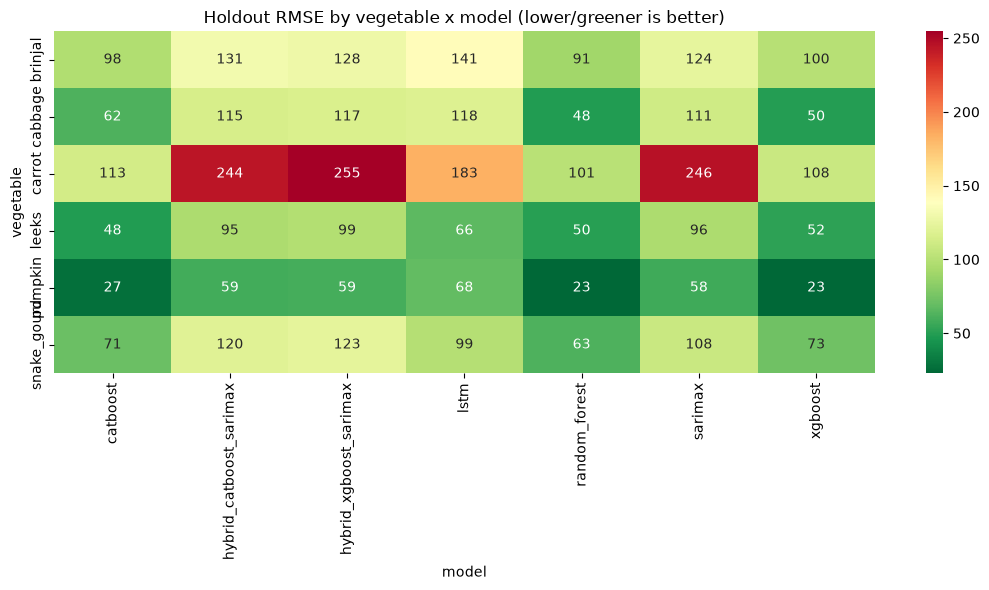

In [5]:
fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(comparison, annot=True, fmt='.0f', cmap='RdYlGn_r', ax=ax)
ax.set_title('Holdout RMSE by vegetable x model (lower/greener is better)')
plt.tight_layout(); plt.show()

## Best model per vegetable

In [6]:
best = comparison.idxmin(axis=1)
best.to_frame('best_model_by_rmse')

,best_model_by_rmse
vegetable,
brinjal,random_forest
cabbage,random_forest
carrot,random_forest
leeks,catboost
pumpkin,random_forest
snake_gourd,random_forest


## R² comparison

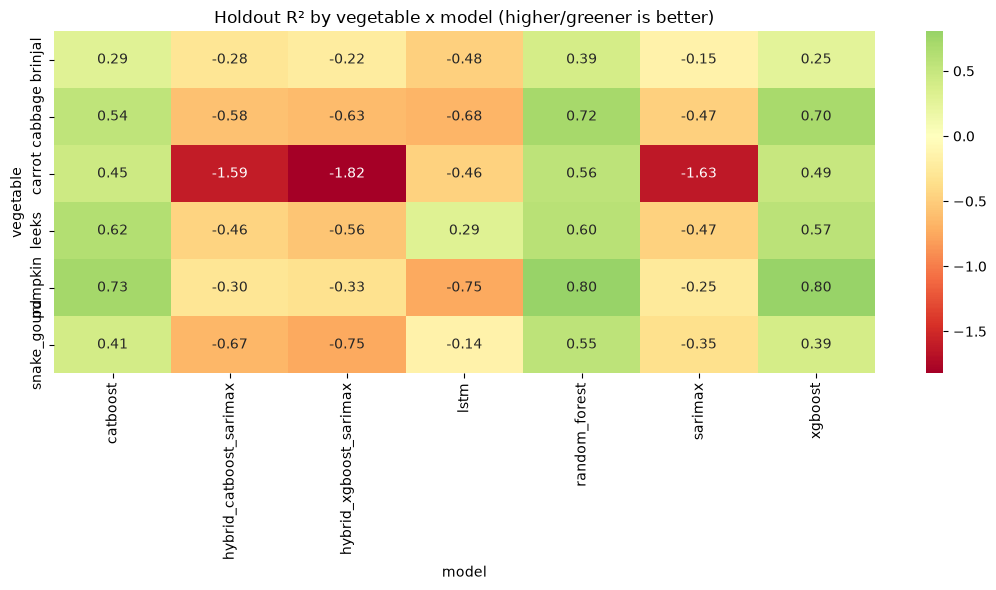

In [7]:
r2_table = results.pivot(index='vegetable', columns='model', values='r2')
fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(r2_table, annot=True, fmt='.2f', cmap='RdYlGn', center=0, ax=ax)
ax.set_title('Holdout R\u00b2 by vegetable x model (higher/greener is better)')
plt.tight_layout(); plt.show()

## Overall model ranking (mean rank across vegetables, by RMSE)

In [8]:
ranks = comparison.rank(axis=1)
ranks.mean().sort_values().to_frame('mean_rank_across_vegetables')

,mean_rank_across_vegetables
model,
random_forest,1.166667
catboost,2.333333
xgboost,2.500000
sarimax,4.833333
hybrid_catboost_sarimax,5.333333
lstm,5.500000
hybrid_xgboost_sarimax,6.333333


---
## Forecast vs. actual (holdout year)

The tables above summarize accuracy as a single number (RMSE/R²). This section plots the actual forecast curve against the real price for the held-out final 52 weeks, so accuracy can be verified visually, not just read off a metric. Loads `results/metrics/holdout_predictions.csv` (written by `scripts/train_all.py` alongside the metrics).

In [9]:
predictions = pd.read_csv('../results/metrics/holdout_predictions.csv', parse_dates=['date'])
predictions.head()

,vegetable,model,date,actual,predicted,predicted_lower,predicted_upper
0,carrot,sarimax,2025-03-24,702.962963,695.630399,274.554576,836.249092
1,carrot,sarimax,2025-03-31,543.666667,667.568338,246.492515,808.187032
2,carrot,sarimax,2025-04-07,627.647059,671.583668,250.507845,812.202361
3,carrot,sarimax,2025-04-14,528.260870,670.921466,249.845643,811.540159
4,carrot,sarimax,2025-04-21,588.518519,670.806481,249.730658,811.425174


### Best model per vegetable: forecast vs. actual

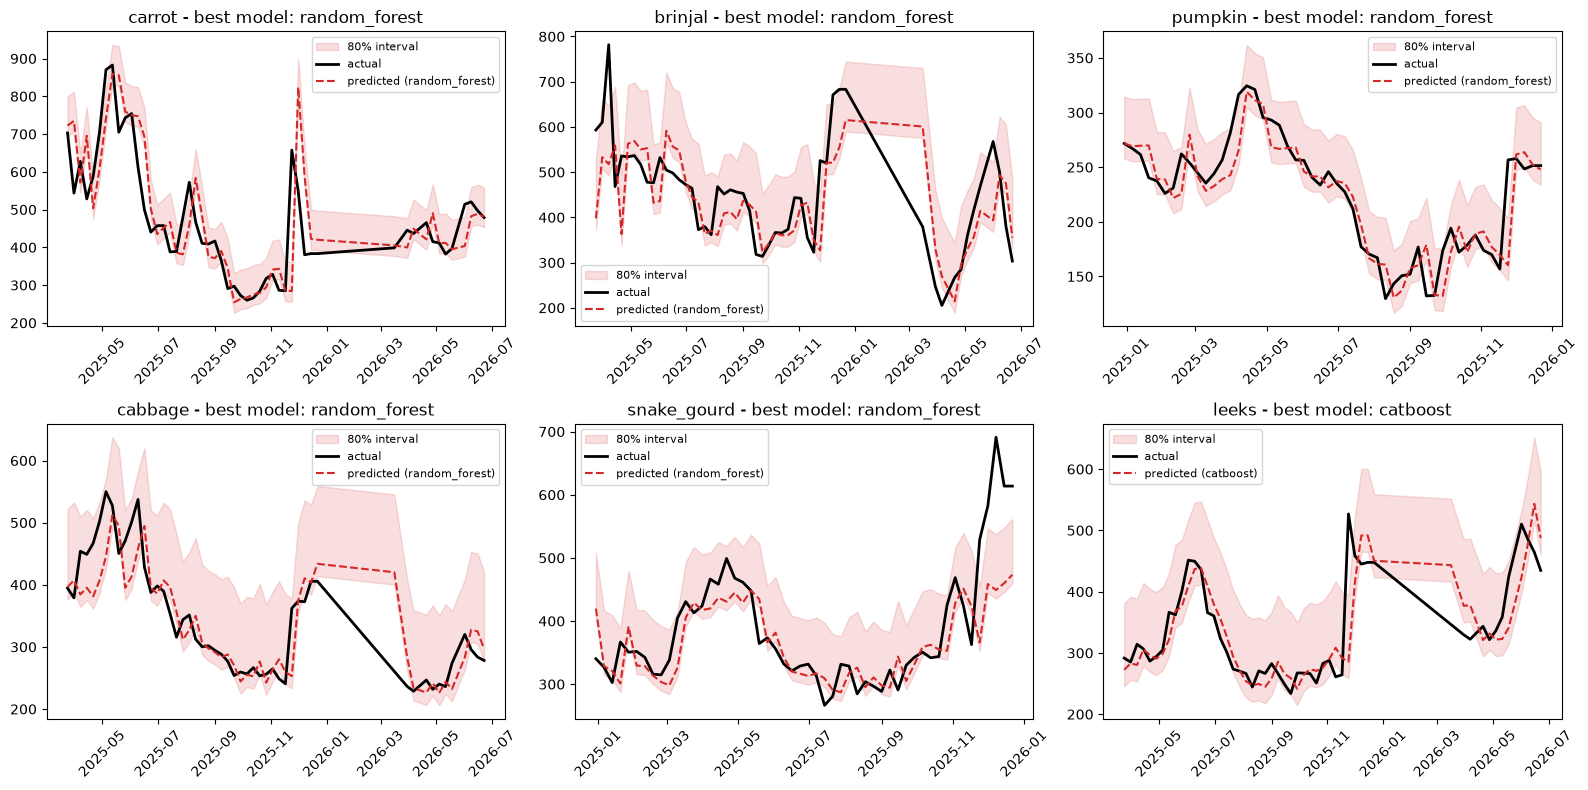

In [10]:
vegetables = results['vegetable'].unique()
best_model = comparison.idxmin(axis=1)

fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=False)
for ax, veg in zip(axes.flat, vegetables):
    model = best_model[veg]
    d = predictions[(predictions['vegetable'] == veg) & (predictions['model'] == model)].sort_values('date')
    ax.fill_between(d['date'], d['predicted_lower'], d['predicted_upper'], color='tab:red', alpha=0.15, label='80% interval')
    ax.plot(d['date'], d['actual'], label='actual', color='black', linewidth=2)
    ax.plot(d['date'], d['predicted'], label=f'predicted ({model})', color='tab:red', linestyle='--')
    ax.set_title(f'{veg} - best model: {model}')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=8)
plt.tight_layout()
fig.savefig('../results/figures/forecast_vs_actual_best_model.png', dpi=150, bbox_inches='tight')
plt.show()

### Prediction interval calibration

Each forecast above also carries an 80% prediction interval (the shaded band), derived from each model's out-of-sample residuals during walk-forward CV (`src.evaluation.metrics.prediction_interval`) — not the holdout's own residuals, so this is a genuine out-of-sample calibration check. `interval_coverage` is the fraction of holdout actuals that actually fell inside the band; it should sit close to the nominal 0.8 if the interval is well-calibrated (well below 0.8 means the band is too narrow, well above means it's wider than it needs to be).

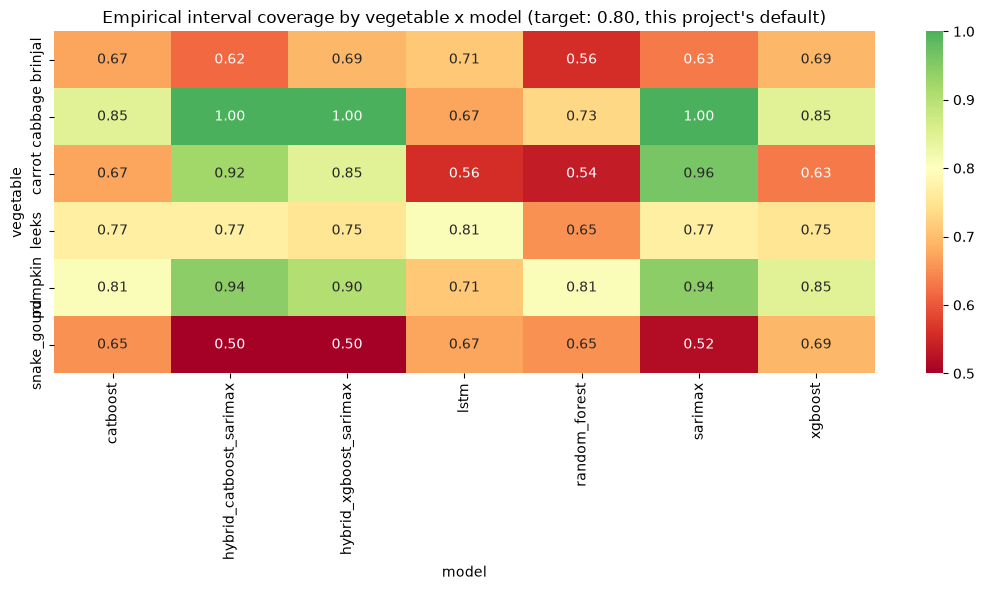

Coverage for each vegetable's best (lowest-RMSE) model:


,interval_coverage
carrot,0.538462
brinjal,0.557692
pumpkin,0.807692
cabbage,0.730769
snake_gourd,0.653846
leeks,0.769231


In [11]:
coverage_table = results.pivot(index='vegetable', columns='model', values='interval_coverage')
fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(coverage_table, annot=True, fmt='.2f', cmap='RdYlGn', center=0.8, vmin=0.5, vmax=1.0, ax=ax)
ax.set_title("Empirical interval coverage by vegetable x model (target: 0.80, this project's default)")
plt.tight_layout(); plt.show()

print('Coverage for each vegetable\'s best (lowest-RMSE) model:')
best_coverage = pd.Series({veg: coverage_table.loc[veg, best_model[veg]] for veg in vegetables})
best_coverage.to_frame('interval_coverage')

### All 7 models vs. actual, per vegetable

One figure per vegetable, saved to `results/figures/` for direct use in the thesis.

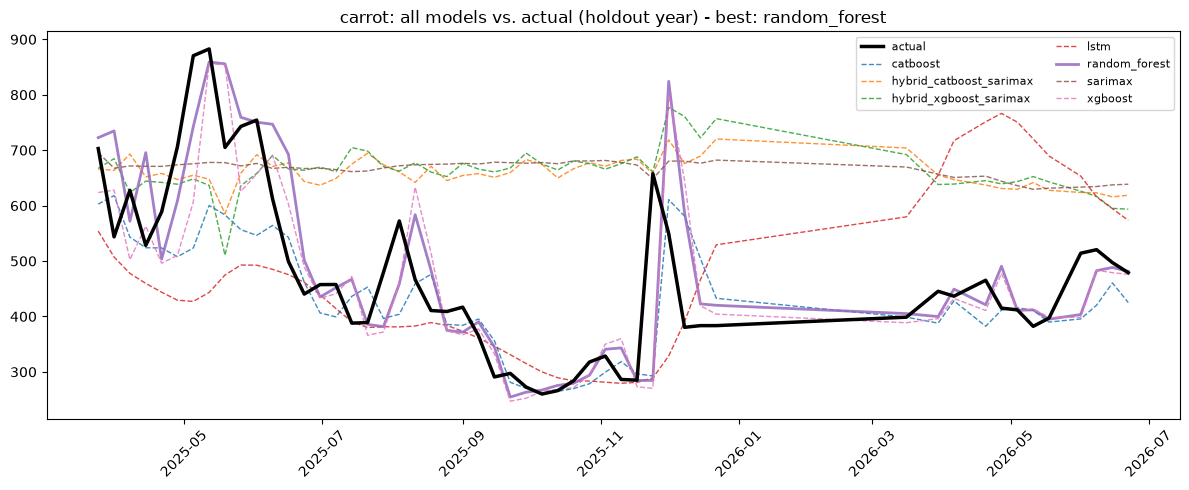

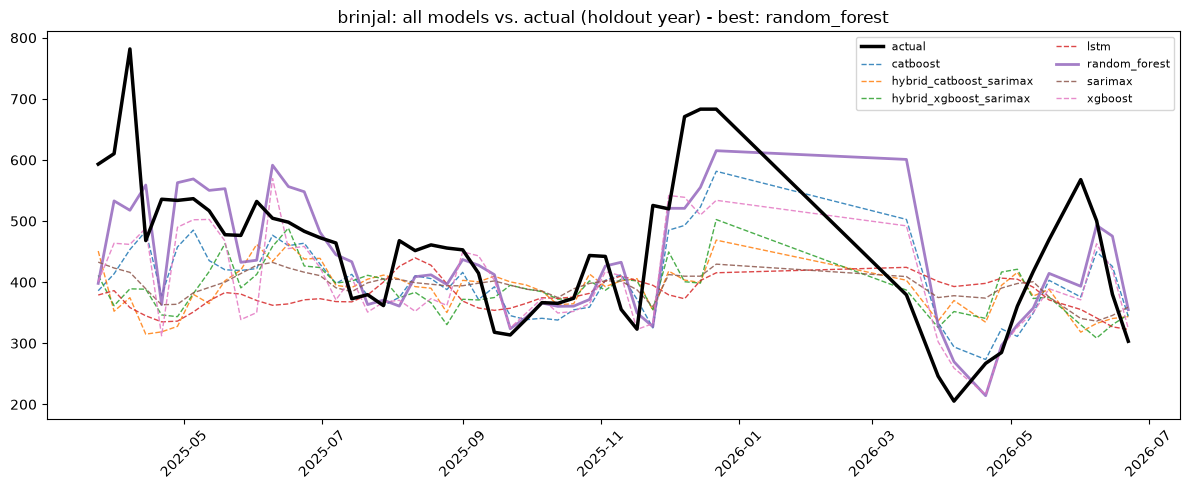

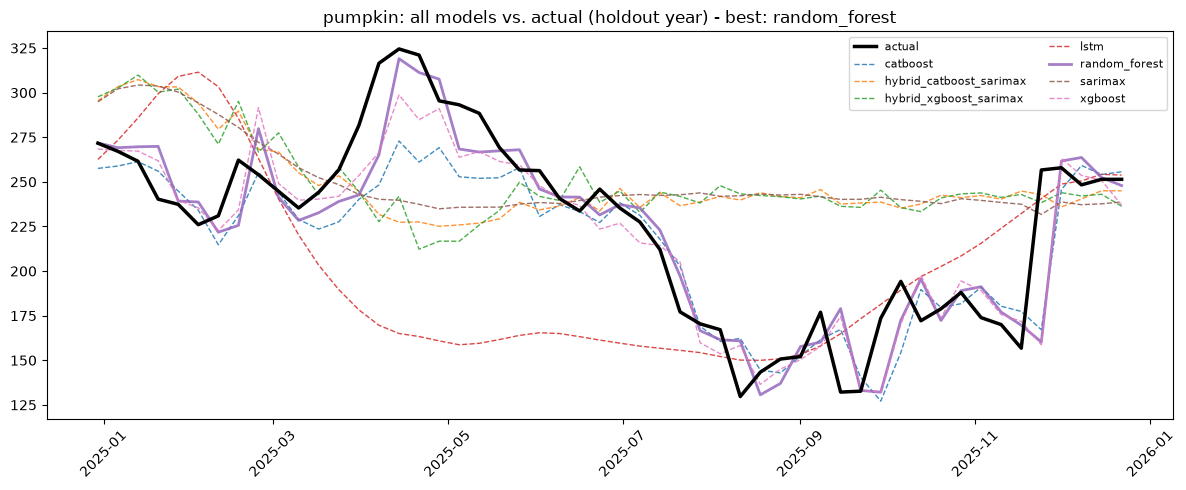

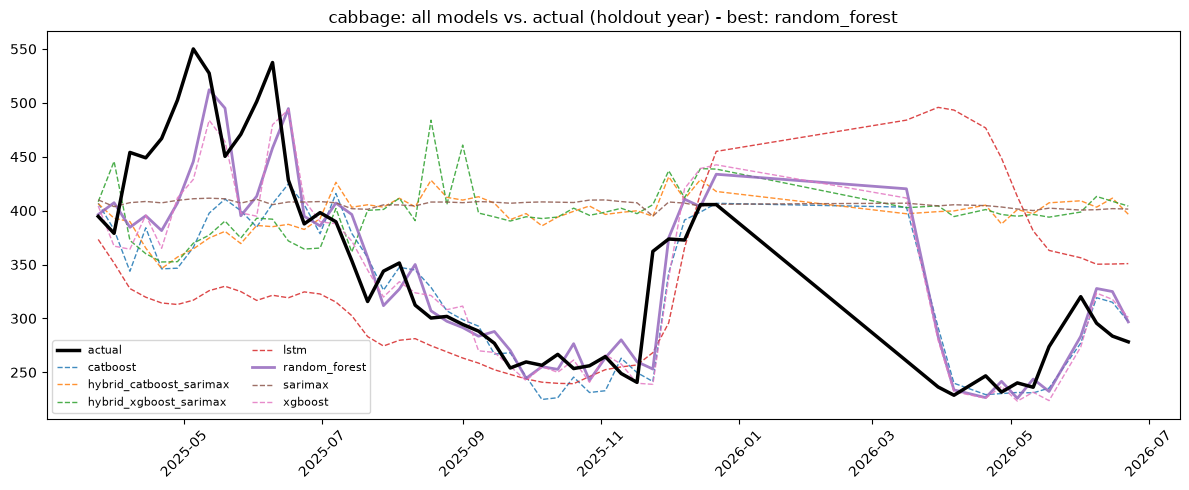

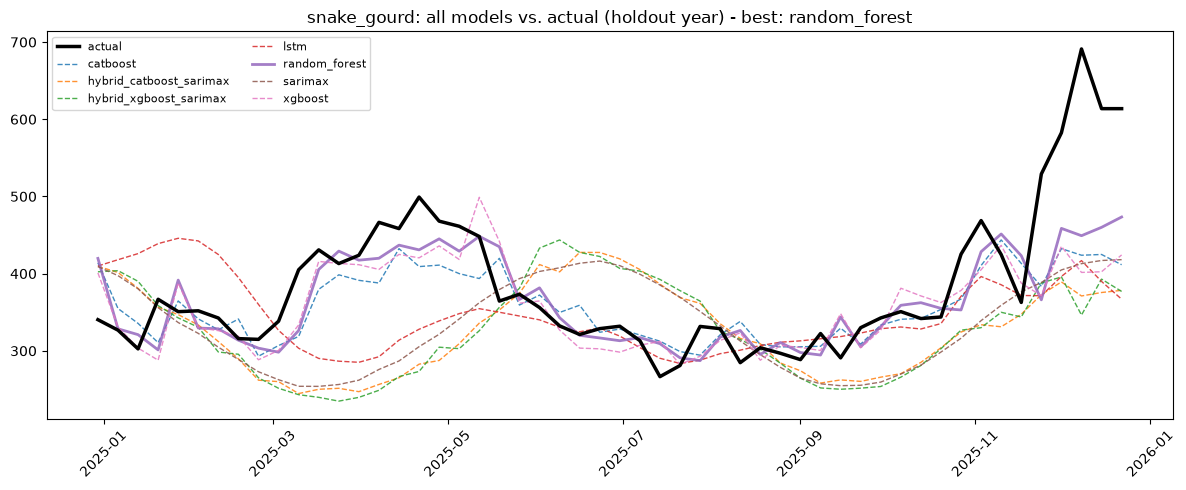

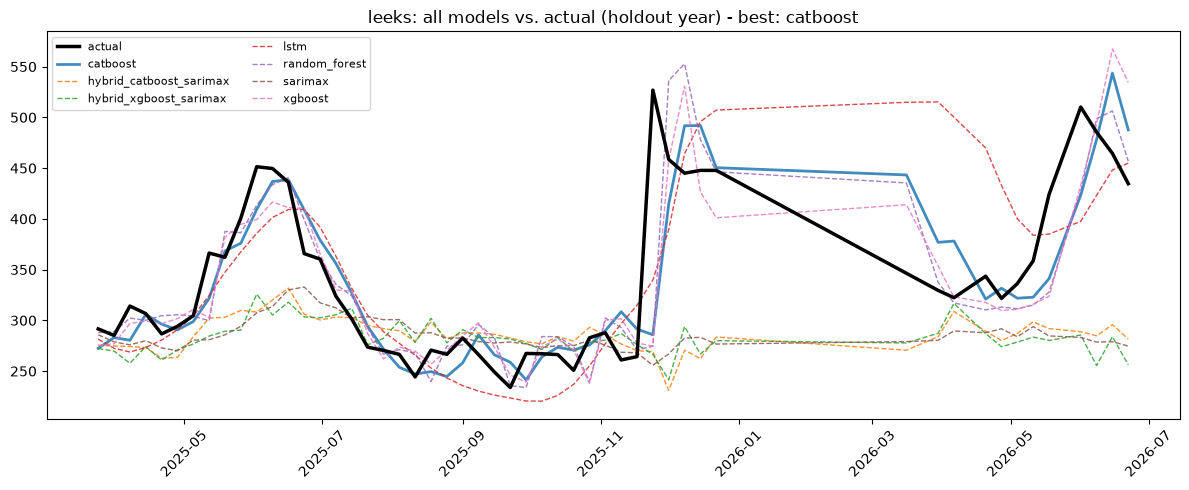

In [12]:
import os
os.makedirs('../results/figures', exist_ok=True)

model_order = comparison.columns.tolist()
for veg in vegetables:
    fig, ax = plt.subplots(figsize=(12, 5))
    actual_plotted = False
    for model in model_order:
        d = predictions[(predictions['vegetable'] == veg) & (predictions['model'] == model)].sort_values('date')
        if not actual_plotted:
            ax.plot(d['date'], d['actual'], label='actual', color='black', linewidth=2.5, zorder=10)
            actual_plotted = True
        style = '-' if model == best_model[veg] else '--'
        lw = 2 if model == best_model[veg] else 1
        ax.plot(d['date'], d['predicted'], label=model, linestyle=style, linewidth=lw, alpha=0.85)
    ax.set_title(f'{veg}: all models vs. actual (holdout year) - best: {best_model[veg]}')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    fig.savefig(f'../results/figures/forecast_vs_actual_{veg}.png', dpi=150, bbox_inches='tight')
    plt.show()

### Residuals (actual - predicted) for the best model, per vegetable

Checks whether errors are randomly scattered around zero (good) or systematically biased (e.g. consistently under-forecasting a rising trend).

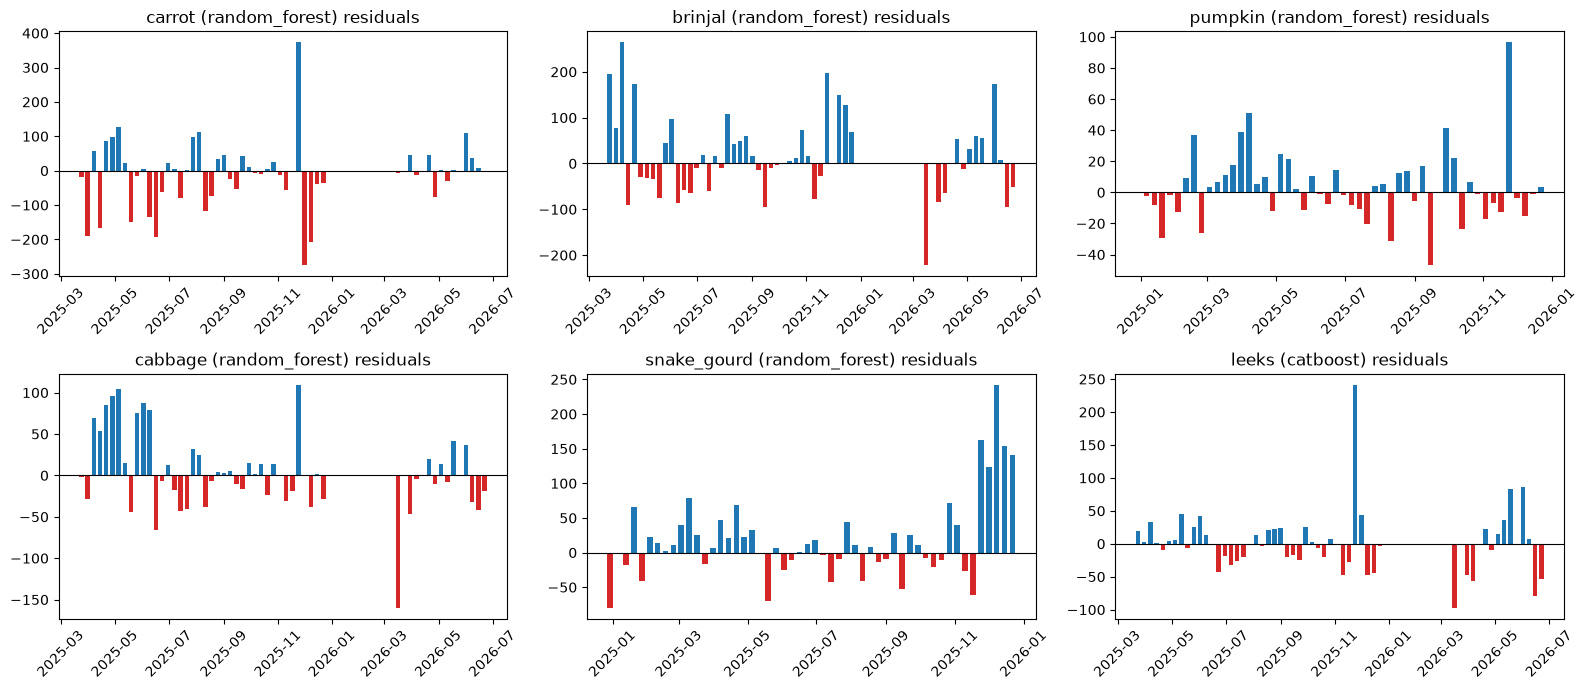

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 7), sharex=False)
for ax, veg in zip(axes.flat, vegetables):
    model = best_model[veg]
    d = predictions[(predictions['vegetable'] == veg) & (predictions['model'] == model)].sort_values('date')
    residual = d['actual'] - d['predicted']
    ax.bar(d['date'], residual, width=5, color=residual.apply(lambda x: 'tab:red' if x < 0 else 'tab:blue'))
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(f'{veg} ({model}) residuals')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()